# Computational Finance – Lab Assignment 3

**Yara Berkelmans — 14639491**  
**Max van Beusekom — 13979345**  
**Marcos Penedo — 16523202**

This notebook covers numerical methods for pricing exotic options under the Black–Scholes framework and smile-aware delta hedging using real SPX market data. It is divided into two sections.

**Section 1** studies two classes of exotic options:
- **Binary (digital) call options** : derivation of the BS PDE and closed-form solution, Monte Carlo simulation, implicit and Crank–Nicolson PDE schemes, sensitivity analysis, option surface $C_d(S,t)$ and delta $\Delta_d$.
- **Up-and-out barrier call options** : closed-form formula via the reflection principle, Monte Carlo with Broadie–Kaya correction and convergence analysis, implicit PDE scheme with Dirichlet barrier boundary, option surface $C(S,t)$ and delta $\Delta$.

**Section 2** implements and evaluates one-step delta hedging on real SPX option data (February 2023):
- **Baseline hedging** : data loading and cleaning, BS delta using market implied volatilities, hedging residuals and SSE.
- **SABR calibration** : lognormal SABR ($\beta=1$) calibrated per maturity slice, smile diagnostics and parameter time series.
- **SABR & Bartlett hedging** : smile-aware SABR delta and Bartlett delta, bucketed SSE/Gain metrics and competition scoreboards.



In [69]:
# all imports 
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import os

PLOT_DIR = "plots"
os.makedirs(PLOT_DIR, exist_ok=True)

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

# base parameters 
S0    = 1.0  
K     = 1.0  
r     = 0.05  
sigma = 0.2  
T     = 1.0 
B     = 1.5    

# Section 1

### 1.1 Black–Scholes PDE

Under the risk-neutral measure $\mathbb{Q}$, the underlying asset price follows the stochastic differential equation:

$$
dS_t = rS_t\,dt + \sigma S_t\,dW_t, \qquad S_0 = 1,
$$

We consider a binary (digital) call option with maturity $T$ and strike price $K$, whose payoff is

$$
C_d(T,S_T) = \mathbf{1}_{\{S_T \ge K\}}.
$$

Let $C_d(t,S)$ denote the option price at time $t$ when the stock price is $S$.

Applying Itô’s lemma to $C_d(t,S_t)$ gives the following:

$$
dC_d =
\left(
\partial_t C_d
+ rS\,\partial_S C_d
+ \frac{\sigma^2}{2}S^2 \partial_{SS} C_d
\right) dt
+ \sigma S\,\partial_S C_d\, dW_t.
$$

Now construct the self-financing hedged portfolio

$$
\Pi_t = C_d - \partial_S C_d \, S.
$$

By construction, the stochastic term cancels, so the portfolio is locally riskless. By the no-arbitrage principle, it must earn the risk-free rate:

$$
d\Pi_t = r\Pi_t\,dt.
$$

Substituting the Itô expansion into the portfolio dynamics yields the Black–Scholes PDE:

$$
\boxed{
\partial_t C_d
+ rS\,\partial_S C_d
+ \frac{\sigma^2}{2}S^2 \partial_{SS} C_d
= rC_d
}
$$

with terminal condition

$$
\boxed{
C_d(T,S) = \mathbf{1}_{\{S \ge K\}}.
}
$$



### 1.2 Closed-form solution

Under the risk-neutral measure, the solution of the stock price SDE is:

$$
S_T = S \exp\left(
\left(r - \frac{\sigma^2}{2}\right)(T-t)
+ \sigma \sqrt{T-t}\, Z
\right),
\qquad Z \sim \mathcal{N}(0,1).
$$

The arbitrage-free price of the digital call is the discounted risk-neutral expectation of its payoff:

$$
C_d(t,S)
=
e^{-r(T-t)}
\mathbb{E}^{\mathbb{Q}}
\left[
\mathbf{1}_{\{S_T \ge K\}}
\,\middle|\,
S_t = S
\right].
$$

Since the expectation of an indicator is a probability, this then becomes:

$$
C_d(t,S)
=
e^{-r(T-t)}
\mathbb{Q}(S_T \ge K \mid S_t = S).
$$

Now,

$$
S_T \ge K
\iff
\log\left(\frac{S_T}{S}\right) \ge \log\left(\frac{K}{S}\right).
$$

Using the explicit form of $S_T$ obtains:

$$
\left(r - \frac{\sigma^2}{2}\right)(T-t)
+ \sigma \sqrt{T-t}\, Z
\ge
\log\left(\frac{K}{S}\right).
$$

Rearrange:

$$
Z \ge
\frac{
\log(K/S)
-
\left(r - \frac{\sigma^2}{2}\right)(T-t)
}{
\sigma\sqrt{T-t}
}.
$$

$$
\mathbb{Q}(S_T \ge K \mid S_t = S)
=
\Phi\left(
\frac{
\log(S/K)
+
\left(r - \frac{\sigma^2}{2}\right)(T-t)
}{
\sigma\sqrt{T-t}
}
\right),
$$

where $\Phi(\cdot)$ is the cumulative distribution function of the standard normal distribution.

The closed-form price of the digital call option is then:

$$
\boxed{
C_d(t,S)
=
e^{-r(T-t)}
\Phi\left(
\frac{
\log(S/K)
+
\left(r - \frac{\sigma^2}{2}\right)(T-t)
}{
\sigma\sqrt{T-t}
}
\right)
}
$$

with

$$
d_-(T-t)
=
\frac{
\log(S/K)
+
\left(r - \frac{\sigma^2}{2}\right)(T-t)
}{
\sigma\sqrt{T-t}
},
$$

the result yields:

$$
\boxed{
C_d(t,S) = e^{-r(T-t)} \Phi(d_-(T-t)).
}
$$



### 1.3 Monte Carlo Pricing

In [88]:
def binary_call_bs(S, K, r, sigma, tau):
    """Closed-form Black-Scholes price for a binary call. tau = T - t."""
    S = np.asarray(S, float)
    d_minus = ((r - 0.5*sigma**2)*tau + np.log(S/K)) / (sigma*np.sqrt(tau))
    return np.exp(-r*tau) * norm.cdf(d_minus)

price_bs = float(binary_call_bs(S0, K, r, sigma, T))

def binary_call_mc(S0, K, r, sigma, T, N_paths=200_000, seed=42):
    """Monte Carlo price via exact GBM simulation."""
    rng = np.random.default_rng(seed)
    Z   = rng.standard_normal(N_paths)
    S_T = S0 * np.exp((r - 0.5*sigma**2)*T + sigma*np.sqrt(T)*Z)
    payoffs = (S_T >= K).astype(float)
    price   = np.exp(-r*T) * np.mean(payoffs)
    std_err = np.exp(-r*T) * np.std(payoffs) / np.sqrt(N_paths)
    return price, std_err

price_mc, se_mc = binary_call_mc(S0, K, r, sigma, T)
print(f"MC price:      {price_mc:.6f}  (se: {se_mc:.6f})")
print(f"Closed-form:   {price_bs:.6f}")
print(f"Difference:    {abs(price_mc - price_bs):.6f}  ({abs(price_mc-price_bs)/price_bs*100:.3f}%)")

MC price:      0.531171  (se: 0.001056)
Closed-form:   0.532325
Difference:    0.001154  (0.217%)


**MC vs Closed-form comparison:**
The Monte Carlo price (0.5312) agrees closely with the closed-form solution (0.5323),
with an absolute difference of 0.0012 (0.217%), well within two standard errors
(se = 0.0011). This confirms the correctness of both implementations. The small
remaining gap is purely due to Monte Carlo sampling noise, which decreases as
$O(1/\sqrt{N})$ with the number of paths.


### 1.4 PDE Pricing: Fully Implicit Scheme and Crank–Nicolson

We discretize the BS PDE on a uniform grid $S\in[0,S_{\max}]$ with $N_S$ nodes and $N_t$ time steps, stepping forward in $\tau = T-t$.

At interior node $i$ the theta-scheme reads:
$$\frac{V_i^{n+1}-V_i^n}{\Delta t} = \theta\,\mathcal{L}V_i^{n+1} + (1-\theta)\,\mathcal{L}V_i^n$$
where $\mathcal{L}V_i = \frac{\sigma^2 S_i^2}{2\Delta S^2}(V_{i+1}-2V_i+V_{i-1}) + \frac{rS_i}{2\Delta S}(V_{i+1}-V_{i-1}) - rV_i$.

- **$\theta=1$ (Fully Implicit)**: Unconditionally stable, first-order in $\Delta t$. Strong numerical diffusion damps oscillations near the discontinuity.
- **$\theta=0.5$ (Crank–Nicolson)**: Unconditionally stable, second-order in $\Delta t$ for smooth data. Can produce Gibbs-like oscillations near the jump at $K$. A standard fix is **Rannacher time-stepping** (run first 2–4 steps as fully implicit, then switch to CN).

**Boundary conditions for binary call:**
- $C_d(\tau, 0) = 0$ — stock at zero never reaches $K$
- $C_d(\tau, S_{\max}) = e^{-r\tau}$ — stock very large, payoff certain
- $C_d(0, S) = \mathbf{1}_{S\geq K}$ — terminal payoff

In [73]:
def build_fd_coeffs(r, sigma, S_grid, dt, theta):
    """Tridiagonal FD coefficients for BS PDE interior nodes."""
    dS = S_grid[1] - S_grid[0]
    S  = S_grid[1:-1]

    # diffusion
    a  = 0.5*sigma**2*S**2/dS**2   

    # advection
    b  = r*S/(2*dS)    
                
    # LHS (implicit)
    lo  = -dt*theta*(a - b)
    mid =  1 + dt*theta*(2*a + r)
    hi  = -dt*theta*(a + b)
    # RHS (explicit)
    lo_r  =  dt*(1-theta)*(a - b)
    mid_r =  1 - dt*(1-theta)*(2*a + r)
    hi_r  =  dt*(1-theta)*(a + b)
    return lo, mid, hi, lo_r, mid_r, hi_r


def pde_binary_call(S0, K, r, sigma, T, S_max=3.0, N_S=400, N_t=400, theta=1.0):
    """Binary call via FD. theta=1: implicit; theta=0.5: Crank-Nicolson."""
    S_grid = np.linspace(0, S_max, N_S+1)
    dt     = T / N_t
    V      = (S_grid >= K).astype(float)
    lo, mid, hi, lo_r, mid_r, hi_r = build_fd_coeffs(r, sigma, S_grid, dt, theta)
    A = np.diag(mid) + np.diag(lo[1:], -1) + np.diag(hi[:-1], 1)
    for n in range(N_t):
        tau_next = (n+1)*dt
        V_int = V[1:-1].copy()
        rhs   = mid_r*V_int
        rhs[:-1] += hi_r[:-1]*V_int[1:]
        rhs[1:]  += lo_r[1:]*V_int[:-1]
        # upper BC
        rhs[-1]  -= hi[-1]*np.exp(-r*tau_next) 
        V[0]    = 0.0
        V[1:-1] = np.linalg.solve(A, rhs)
        V[-1]   = np.exp(-r*tau_next)
    return np.interp(S0, S_grid, V), S_grid, V

price_impl, S_grid, V_impl = pde_binary_call(S0, K, r, sigma, T, theta=1.0)
price_cn,   _,      V_cn   = pde_binary_call(S0, K, r, sigma, T, theta=0.5)
print(f"Fully Implicit:  {price_impl:.6f}")
print(f"Crank-Nicolson:  {price_cn:.6f}")
print(f"Closed-form:     {price_bs:.6f}")
print(f"MC:              {price_mc:.6f}")


Fully Implicit:  0.529937
Crank-Nicolson:  0.529959
Closed-form:     0.532325
MC:              0.531171


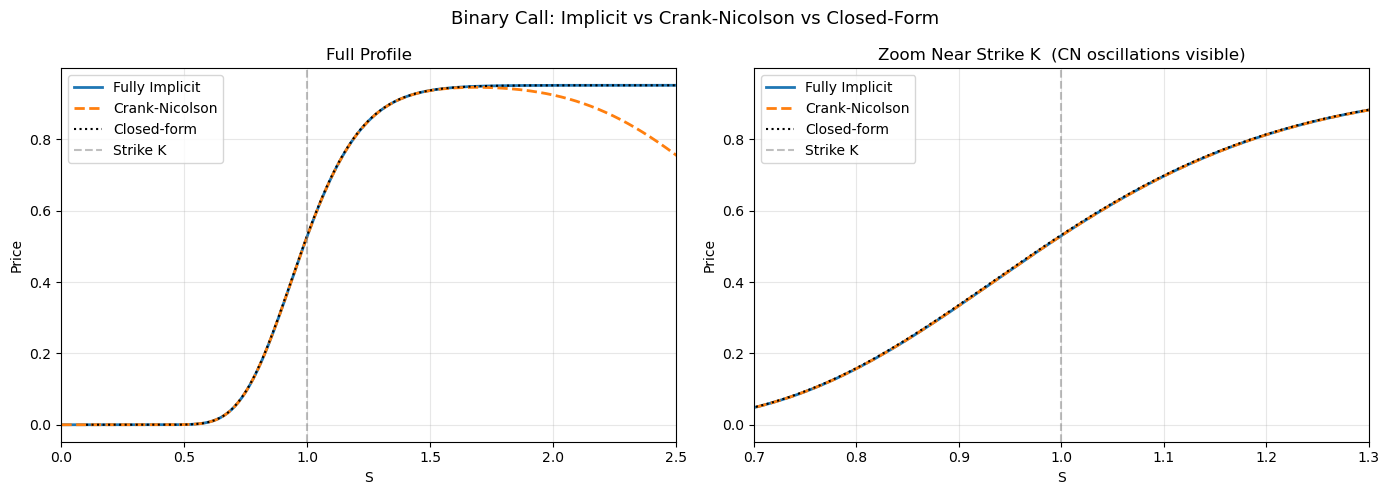

In [74]:
S_vals  = np.linspace(0.1, 2.5, 300)
cf_vals = binary_call_bs(S_vals, K, r, sigma, T)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, xlim, title in zip(axes,
        [(0, 2.5), (0.7, 1.3)],
        ['Full Profile', 'Zoom Near Strike K  (CN oscillations visible)']):
    ax.plot(S_grid, V_impl, label='Fully Implicit', lw=2)
    ax.plot(S_grid, V_cn,   label='Crank-Nicolson', lw=2, ls='--')
    ax.plot(S_vals, cf_vals, label='Closed-form', lw=1.5, color='k', ls=':')
    ax.axvline(K, color='gray', ls='--', alpha=0.5, label='Strike K')
    ax.set_xlim(*xlim); ax.set_xlabel('S'); ax.set_ylabel('Price')
    ax.set_title(title); ax.legend()
plt.suptitle('Binary Call: Implicit vs Crank-Nicolson vs Closed-Form', fontsize=13)
plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/binary_pde_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

**Comparison summary:**
- Both schemes converge to the closed-form; differences are small for 400 time steps.
- Near the discontinuity at $K$ the CN scheme shows mild oscillations (right panel). The fully implicit scheme smears the solution slightly but stays monotone.
- For production use: apply Rannacher stepping or increase $N_t$ to suppress CN oscillations.

<>:13: SyntaxWarning: invalid escape sequence '\,'
<>:13: SyntaxWarning: invalid escape sequence '\,'
/var/folders/wh/_5qlpchn32q3qvtv8splhn8w0000gn/T/ipykernel_15414/3062158926.py:13: SyntaxWarning: invalid escape sequence '\,'
  ax.set_title('Binary Call Option Surface $C_d(S,\,τ)$')


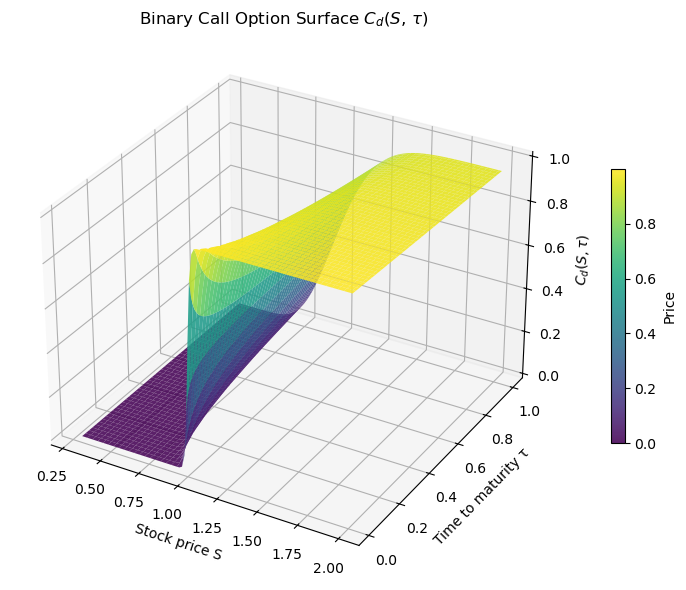

In [89]:
S_r   = np.linspace(0.3, 2.0, 100)
tau_r = np.linspace(0.01, T, 100)
SS, TT = np.meshgrid(S_r, tau_r)
CC = binary_call_bs(SS, K, r, sigma, TT)

fig = plt.figure(figsize=(11, 6))
ax  = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(SS, TT, CC, cmap='viridis', alpha=0.87)
fig.colorbar(surf, ax=ax, shrink=0.5, label='Price')
ax.set_xlabel('Stock price S')
ax.set_ylabel('Time to maturity τ')
ax.set_zlabel('$C_d(S,τ)$')
ax.set_title('Binary Call Option Surface $C_d(S,\,τ)$')
plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/binary_option_surface.png", dpi=150, bbox_inches='tight')
plt.show()

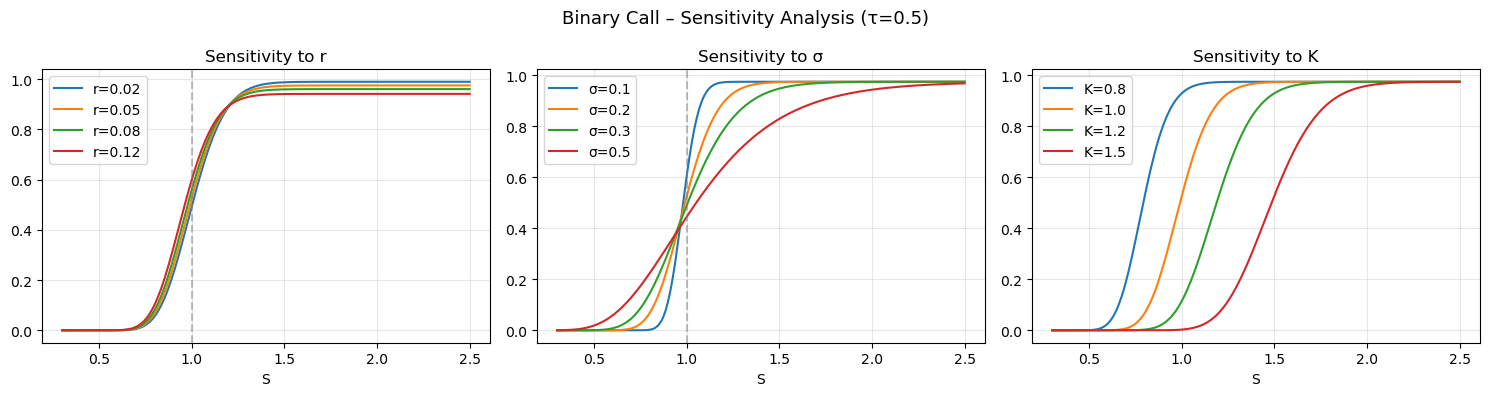

In [76]:
S_range   = np.linspace(0.3, 2.5, 200)
tau_fixed = 0.5

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for r_val in [0.02, 0.05, 0.08, 0.12]:
    axes[0].plot(S_range, binary_call_bs(S_range, K, r_val, sigma, tau_fixed), label=f'r={r_val}')
axes[0].axvline(K, color='gray', ls='--', alpha=0.5)
axes[0].set_title('Sensitivity to r'); axes[0].set_xlabel('S'); axes[0].legend()

for sv in [0.1, 0.2, 0.3, 0.5]:
    axes[1].plot(S_range, binary_call_bs(S_range, K, r, sv, tau_fixed), label=f'σ={sv}')
axes[1].axvline(K, color='gray', ls='--', alpha=0.5)
axes[1].set_title('Sensitivity to σ'); axes[1].set_xlabel('S'); axes[1].legend()

for Kv in [0.8, 1.0, 1.2, 1.5]:
    axes[2].plot(S_range, binary_call_bs(S_range, Kv, r, sigma, tau_fixed), label=f'K={Kv}')
axes[2].set_title('Sensitivity to K'); axes[2].set_xlabel('S'); axes[2].legend()

plt.suptitle('Binary Call – Sensitivity Analysis (τ=0.5)', fontsize=13)
plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/binary_sensitivity.png", dpi=150, bbox_inches='tight')
plt.show()

**Observations:**
- **$r$**: Higher rate raises the risk-neutral drift, shifting the sigmoid right and increasing the ATM price slightly.
- **$\sigma$**: Unlike a vanilla call, higher volatility *decreases* the ATM binary price , more uncertainty around $K$ means the payoff is less certain. OTM options gain value while ITM options lose it.
- **$K$**: Shifts the transition point; a higher strike requires a larger final stock price for the payoff.

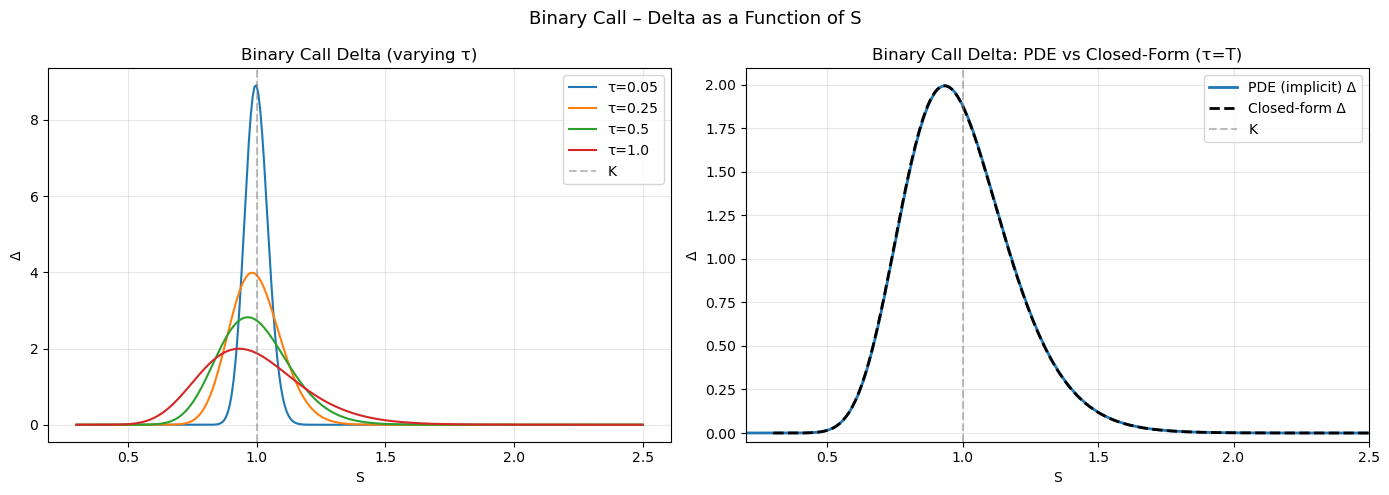

In [77]:
def binary_call_delta(S, K, r, sigma, tau):
    """Analytical delta of the binary call."""
    S = np.asarray(S, float)
    d_minus = ((r - 0.5*sigma**2)*tau + np.log(S/K)) / (sigma*np.sqrt(tau))
    return np.exp(-r*tau) * norm.pdf(d_minus) / (S*sigma*np.sqrt(tau))

S_range = np.linspace(0.3, 2.5, 300)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Delta for varying maturities
for tv in [0.05, 0.25, 0.5, 1.0]:
    axes[0].plot(S_range, binary_call_delta(S_range, K, r, sigma, tv), label=f'τ={tv}')
axes[0].axvline(K, color='gray', ls='--', alpha=0.5, label='K')
axes[0].set_title('Binary Call Delta (varying τ)')
axes[0].set_xlabel('S'); axes[0].set_ylabel('Δ'); axes[0].legend()

# PDE delta vs closed-form
dS      = S_grid[1] - S_grid[0]
delta_pde = np.gradient(V_impl, dS)
axes[1].plot(S_grid, delta_pde, label='PDE (implicit) Δ', lw=2)
axes[1].plot(S_range, binary_call_delta(S_range, K, r, sigma, T),
             '--', label='Closed-form Δ', lw=2, color='k')
axes[1].axvline(K, color='gray', ls='--', alpha=0.5, label='K')
axes[1].set_xlim(0.2, 2.5); axes[1].set_ylim(-0.05, None)
axes[1].set_title('Binary Call Delta: PDE vs Closed-Form (τ=T)')
axes[1].set_xlabel('S'); axes[1].set_ylabel('Δ'); axes[1].legend()

plt.suptitle('Binary Call – Delta as a Function of S', fontsize=13)
plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/binary_delta.png", dpi=150, bbox_inches='tight')
plt.show()

# Part 2: Up-and-Out Barrier Call Option

## 2.1 Closed-Form Formula

Consider an up-and-out barrier call option with maturity $T$, strike $K$, and barrier level $B$, with $B \ge K$.

Its payoff is:

$$
C(H) = (S_T - K)^+ \mathbf{1}_{\{M_0^T < B\}},
$$

where

$$
M_0^T := \max_{0 \le s \le T} S_s
$$

is the running maximum of the stock price over the interval $[0,T]$.

This means:
- if the stock price ever reaches or exceeds the barrier $B$ before maturity, the option is knocked out and becomes worthless;
- otherwise, it behaves like a standard European call option.

Using the reflection principle for geometric Brownian motion, the closed-form price of the up-and-out call is

$$
\begin{aligned}
C(t,T,S_t,M_0^t)
&= C(H) \\
&= S_t \mathbf{1}_{\{M_0^t < B\}}
\left[
\Phi\!\left(\delta_+^{T-t}\!\left(\frac{S_t}{K}\right)\right)
-
\Phi\!\left(\delta_+^{T-t}\!\left(\frac{S_t}{B}\right)\right)
\right] \\
&\quad
- S_t \mathbf{1}_{\{M_0^t < B\}}
\left(\frac{B}{S_t}\right)^{1+\frac{2r}{\sigma^2}}
\left[
\Phi\!\left(\delta_+^{T-t}\!\left(\frac{B^2}{KS_t}\right)\right)
-
\Phi\!\left(\delta_+^{T-t}\!\left(\frac{B}{S_t}\right)\right)
\right] \\
&\quad
- e^{-r(T-t)} K \mathbf{1}_{\{M_0^t < B\}}
\left[
\Phi\!\left(\delta_-^{T-t}\!\left(\frac{S_t}{K}\right)\right)
-
\Phi\!\left(\delta_-^{T-t}\!\left(\frac{S_t}{B}\right)\right)
\right] \\
&\quad
+ \left(\frac{S_t}{B}\right)^{1-\frac{2r}{\sigma^2}}
e^{-r(T-t)} K \mathbf{1}_{\{M_0^t < B\}}
\left[
\Phi\!\left(\delta_-^{T-t}\!\left(\frac{B^2}{KS_t}\right)\right)
-
\Phi\!\left(\delta_-^{T-t}\!\left(\frac{B}{S_t}\right)\right)
\right].
\end{aligned}
$$

Here, the functions $\delta_\pm^\tau(z)$ are defined by

$$
\delta_\pm^\tau(z)
=
\frac{
\log z + \left(r \pm \frac{\sigma^2}{2}\right)\tau
}{
\sigma \sqrt{\tau}
},
\qquad z > 0,\;\tau > 0.
$$



This formula can be interpreted as the value of a standard European call minus the contribution of all paths that cross the barrier, obtained through the reflection principle (also called the image method).

In the numerical implementation below, we use this analytical formula as a benchmark for comparison with the Monte Carlo simulation.

In [78]:
def delta_pm(tau, z, r, sigma):
    d_p = (np.log(z) + (r + 0.5*sigma**2)*tau) / (sigma*np.sqrt(tau))
    d_m = (np.log(z) + (r - 0.5*sigma**2)*tau) / (sigma*np.sqrt(tau))
    return d_p, d_m

def barrier_call_cf(S, K, B, r, sigma, tau):
    """Closed-form price for continuous up-and-out barrier call."""
    S   = np.atleast_1d(np.asarray(S, float))
    out = np.zeros_like(S)
    mask = S < B
    Sm   = S[mask]
    mu   = 2*r/sigma**2
    dp1, dm1 = delta_pm(tau, Sm/K,        r, sigma)
    dp2, dm2 = delta_pm(tau, Sm/B,        r, sigma)
    dp3, dm3 = delta_pm(tau, B**2/(K*Sm), r, sigma)
    dp4, dm4 = delta_pm(tau, B/Sm,        r, sigma)
    t1 = Sm*(norm.cdf(dp1) - norm.cdf(dp2))
    t2 = Sm*(B/Sm)**(1+mu)*(norm.cdf(dp3) - norm.cdf(dp4))
    t3 = np.exp(-r*tau)*K*(norm.cdf(dm1) - norm.cdf(dm2))
    t4 = (Sm/B)**(1-mu)*np.exp(-r*tau)*K*(norm.cdf(dm3) - norm.cdf(dm4))
    out[mask] = np.maximum(t1 - t2 - t3 + t4, 0)
    return float(out[0]) if len(S)==1 else out

price_cf = barrier_call_cf(S0, K, B, r, sigma, T)
print(f"Up-and-out barrier call (closed-form): {price_cf:.6f}")

Up-and-out barrier call (closed-form): 0.076224


### 2.2 Monte Carlo with Broadie–Kaya Correction

Discrete-time MC monitoring underestimates barrier crossing probability because paths may cross and return between monitoring dates. The correction (Broadie, Glasserman & Kou 1997) shifts the effective barrier:

$$C_m(H) \approx C\!\left(H\,e^{\beta_1\sigma\sqrt{T/m}}\right), \quad \beta_1 = -\frac{\zeta(1/2)}{\sqrt{2\pi}} \approx 0.5826$$

The barrier is shifted **upward** (away from $S_0$) to account for the discrete overshoot bias. The residual error after correction is $O(1/m)$ vs $O(1/\sqrt{m})$ without it.

In [87]:
# Broadie-Glasserman-Kou constant
beta1 = 0.5826  

def barrier_call_mc(S0, K, B, r, sigma, T, N_paths=200_000, m=252,
                    seed=42, apply_correction=True):
    """MC price for up-and-out barrier call.
    m: monitoring steps. apply_correction: Broadie-Kaya barrier shift."""
    rng   = np.random.default_rng(seed)
    dt    = T / m
    B_eff = B * np.exp(beta1*sigma*np.sqrt(T/m)) if apply_correction else B
    Z       = rng.standard_normal((N_paths, m))
    log_S   = np.log(S0) + np.cumsum((r - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*Z, axis=1)
    S_paths = np.exp(log_S)
    S_T     = S_paths[:, -1]
    S_max   = S_paths.max(axis=1)
    payoff  = np.maximum(S_T - K, 0) * (S_max < B_eff)
    price   = np.exp(-r*T) * np.mean(payoff)
    se      = np.exp(-r*T) * np.std(payoff) / np.sqrt(N_paths)
    return price, se

price_mc_corr,   se_corr   = barrier_call_mc(S0, K, B, r, sigma, T, apply_correction=True)
price_mc_nocorr, se_nocorr = barrier_call_mc(S0, K, B, r, sigma, T, apply_correction=False)

print(f"Closed-form:           {price_cf:.6f}")
print(f"MC (corrected):        {price_mc_corr:.6f}  (se: {se_corr:.6f})")
print(f"MC (no correction):    {price_mc_nocorr:.6f}  (se: {se_nocorr:.6f})")
print(f"Error corrected:       {abs(price_mc_corr   - price_cf):.6f}")
print(f"Error no correction:   {abs(price_mc_nocorr - price_cf):.6f}")

Closed-form:           0.076224
MC (corrected):        0.079601  (se: 0.000249)
MC (no correction):    0.077971  (se: 0.000245)
Error corrected:       0.003378
Error no correction:   0.001747


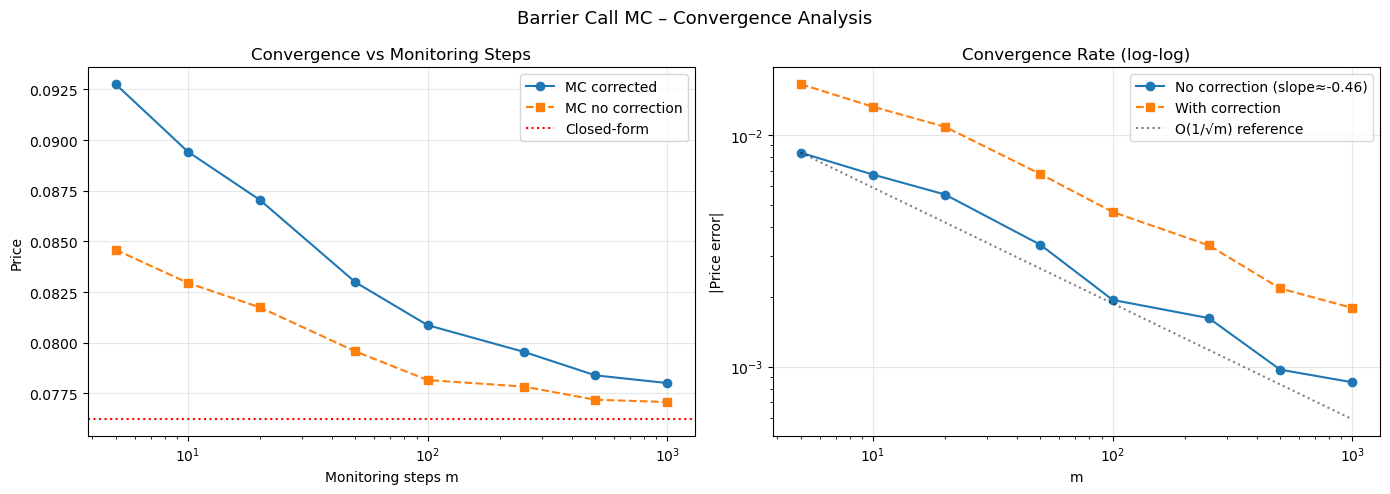

Fitted slope (no correction): -0.461  (theory: -0.5)


In [80]:
m_values  = [5, 10, 20, 50, 100, 252, 500, 1000]
mc_corr   = [barrier_call_mc(S0,K,B,r,sigma,T,N_paths=100_000,m=m,apply_correction=True, seed=0)[0]
             for m in m_values]
mc_nocorr = [barrier_call_mc(S0,K,B,r,sigma,T,N_paths=100_000,m=m,apply_correction=False,seed=0)[0]
             for m in m_values]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].semilogx(m_values, mc_corr,   'o-', label='MC corrected')
axes[0].semilogx(m_values, mc_nocorr, 's--', label='MC no correction')
axes[0].axhline(price_cf, color='red', ls=':', label='Closed-form')
axes[0].set_xlabel('Monitoring steps m'); axes[0].set_ylabel('Price')
axes[0].set_title('Convergence vs Monitoring Steps'); axes[0].legend()

errors_corr   = [abs(p - price_cf) for p in mc_corr]
errors_nocorr = [abs(p - price_cf) for p in mc_nocorr]
log_m = np.log(m_values)
slope, _ = np.polyfit(log_m, np.log(np.maximum(errors_nocorr, 1e-9)), 1)

axes[1].loglog(m_values, errors_nocorr, 'o-', label=f'No correction (slope≈{slope:.2f})')
axes[1].loglog(m_values, np.maximum(errors_corr, 1e-9), 's--', label='With correction')
ref = np.array(m_values, float)**(-0.5)*errors_nocorr[0]*m_values[0]**0.5
axes[1].loglog(m_values, ref, 'k:', alpha=0.5, label='O(1/√m) reference')
axes[1].set_xlabel('m'); axes[1].set_ylabel('|Price error|')
axes[1].set_title('Convergence Rate (log-log)'); axes[1].legend()

plt.suptitle('Barrier Call MC – Convergence Analysis', fontsize=13)
plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/barrier_mc_convergence.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"Fitted slope (no correction): {slope:.3f}  (theory: -0.5)")

**Convergence rate interpretation:**

The theoretical result $C_m(H) = C(H) + O(1/\sqrt{m})$ predicts a log-log slope of $-0.5$ for the uncorrected estimator. The fitted slope above confirms this empirically.

After applying the Broadie–Kaya correction, the $O(1/\sqrt{m})$ bias is removed and the residual error drops to $O(1/m)$, one full order better. This is clearly visible: even with $m=5$ steps the corrected price is already close to the closed-form, while the uncorrected price needs hundreds of steps to achieve the same accuracy.

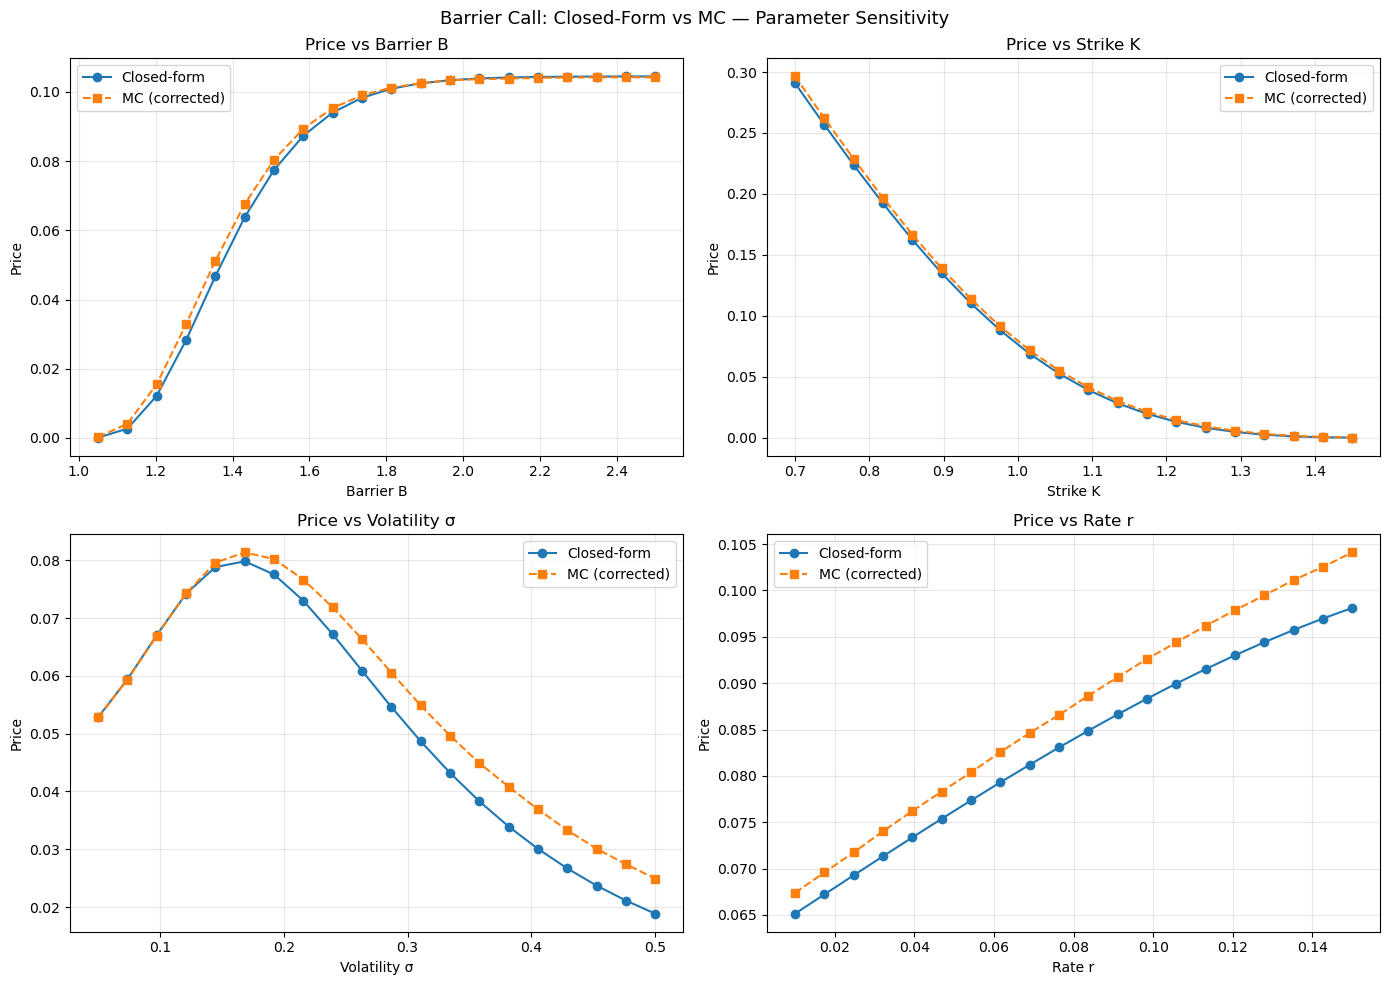

In [81]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# vs barrier B
B_vals = np.linspace(1.05, 2.5, 20)
cf_B = [barrier_call_cf(S0,K,bv,r,sigma,T) for bv in B_vals]
mc_B = [barrier_call_mc(S0,K,bv,r,sigma,T,N_paths=80_000,seed=0)[0] for bv in B_vals]
axes[0,0].plot(B_vals, cf_B, 'o-', label='Closed-form')
axes[0,0].plot(B_vals, mc_B, 's--', label='MC (corrected)')
axes[0,0].set_xlabel('Barrier B'); axes[0,0].set_title('Price vs Barrier B'); axes[0,0].legend()

# vs strike K
K_vals = np.linspace(0.7, B-0.05, 20)
cf_K = [barrier_call_cf(S0,kv,B,r,sigma,T) for kv in K_vals]
mc_K = [barrier_call_mc(S0,kv,B,r,sigma,T,N_paths=80_000,seed=0)[0] for kv in K_vals]
axes[0,1].plot(K_vals, cf_K, 'o-', label='Closed-form')
axes[0,1].plot(K_vals, mc_K, 's--', label='MC (corrected)')
axes[0,1].set_xlabel('Strike K'); axes[0,1].set_title('Price vs Strike K'); axes[0,1].legend()

# vs sigma
sv_vals = np.linspace(0.05, 0.5, 20)
cf_sv = [barrier_call_cf(S0,K,B,r,sv,T) for sv in sv_vals]
mc_sv = [barrier_call_mc(S0,K,B,r,sv,T,N_paths=80_000,seed=0)[0] for sv in sv_vals]
axes[1,0].plot(sv_vals, cf_sv, 'o-', label='Closed-form')
axes[1,0].plot(sv_vals, mc_sv, 's--', label='MC (corrected)')
axes[1,0].set_xlabel('Volatility σ'); axes[1,0].set_title('Price vs Volatility σ'); axes[1,0].legend()

# vs r
r_vals = np.linspace(0.01, 0.15, 20)
cf_r = [barrier_call_cf(S0,K,B,rv,sigma,T) for rv in r_vals]
mc_r = [barrier_call_mc(S0,K,B,rv,sigma,T,N_paths=80_000,seed=0)[0] for rv in r_vals]
axes[1,1].plot(r_vals, cf_r, 'o-', label='Closed-form')
axes[1,1].plot(r_vals, mc_r, 's--', label='MC (corrected)')
axes[1,1].set_xlabel('Rate r'); axes[1,1].set_title('Price vs Rate r'); axes[1,1].legend()

for ax in axes.flat: ax.set_ylabel('Price')
plt.suptitle('Barrier Call: Closed-Form vs MC — Parameter Sensitivity', fontsize=13)
plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/barrier_param_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

**Parameter observations:**
- **Barrier $B$**: As $B\to\infty$ the price approaches a vanilla call. As $B\to K^+$ the price goes to zero (any upward move immediately knocks out the option).
- **Strike $K$**: Higher $K$ reduces $(S_T-K)^+$, monotonically lowering the price.
- **Volatility $\sigma$**: Non-monotone, higher $\sigma$ raises vanilla value but also increases knock-out probability. The price typically peaks at intermediate $\sigma$.
- **Rate $r$**: Higher $r$ raises the drift toward $B$ (more knock-outs) but also increases the forward value. Net effect is non-monotone and depends on proximity to $B$.

### 2.3 PDE Pricing: Implicit Scheme for Barrier Call

The barrier enforces a **Dirichlet condition** at $S=B$:
$$C(\tau, B) = 0 \quad \forall\,\tau > 0$$

Implementation: set $S_{\max}=B$ so the upper boundary *is* the barrier, and impose $V(\tau,B)=0$ at every time step. Terminal condition is the vanilla call payoff $(S-K)^+$.

PDE (implicit):   0.076144
Closed-form:      0.076224
MC (corrected):   0.079601


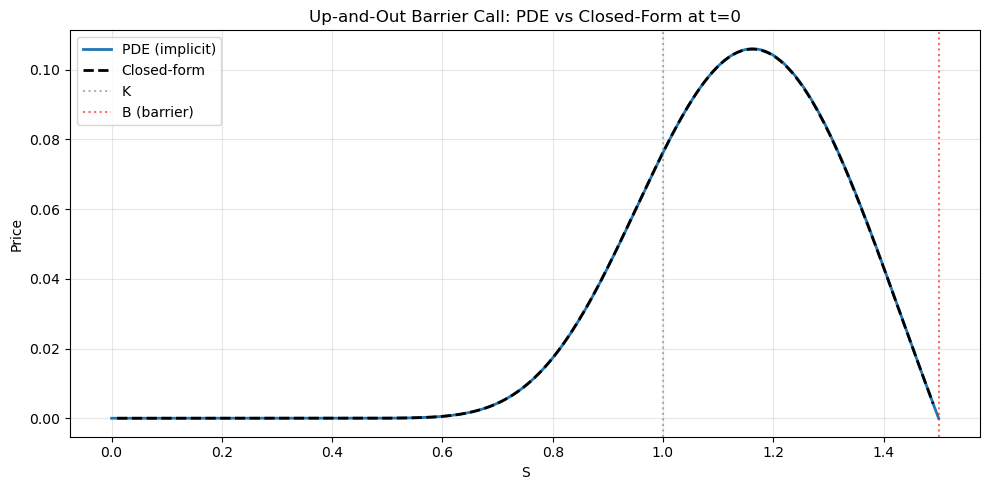

In [82]:
def pde_barrier_call(S0, K, B, r, sigma, T, N_S=400, N_t=400, theta=1.0):
    """Up-and-out barrier call via FD. Upper boundary = barrier B = 0."""
    S_grid = np.linspace(0, B, N_S+1)
    dt     = T / N_t
    V      = np.maximum(S_grid - K, 0).astype(float)
    V[-1]  = 0.0   # knocked out at barrier
    lo, mid, hi, lo_r, mid_r, hi_r = build_fd_coeffs(r, sigma, S_grid, dt, theta)
    A = np.diag(mid) + np.diag(lo[1:], -1) + np.diag(hi[:-1], 1)
    for n in range(N_t):
        V_int = V[1:-1].copy()
        rhs   = mid_r*V_int
        rhs[:-1] += hi_r[:-1]*V_int[1:]
        rhs[1:]  += lo_r[1:]*V_int[:-1]
        # Both BCs are zero — no extra terms needed
        V[0]    = 0.0
        V[1:-1] = np.maximum(np.linalg.solve(A, rhs), 0)
        V[-1]   = 0.0   # barrier
    return np.interp(S0, S_grid, V), S_grid, V

price_pde_b, S_b, V_b = pde_barrier_call(S0, K, B, r, sigma, T)
print(f"PDE (implicit):   {price_pde_b:.6f}")
print(f"Closed-form:      {price_cf:.6f}")
print(f"MC (corrected):   {price_mc_corr:.6f}")

# Profile comparison
S_rng = np.linspace(0.01, B-0.01, 300)
cf_profile = barrier_call_cf(S_rng, K, B, r, sigma, T)

plt.figure()
plt.plot(S_b, V_b, label='PDE (implicit)', lw=2)
plt.plot(S_rng, cf_profile, '--', label='Closed-form', lw=2, color='k')
plt.axvline(K, color='gray',  ls=':', alpha=0.6, label='K')
plt.axvline(B, color='red',   ls=':', alpha=0.6, label='B (barrier)')
plt.xlabel('S'); plt.ylabel('Price')
plt.title('Up-and-Out Barrier Call: PDE vs Closed-Form at t=0')
plt.legend(); plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/barrier_pde_profile.png", dpi=150, bbox_inches='tight')
plt.show()

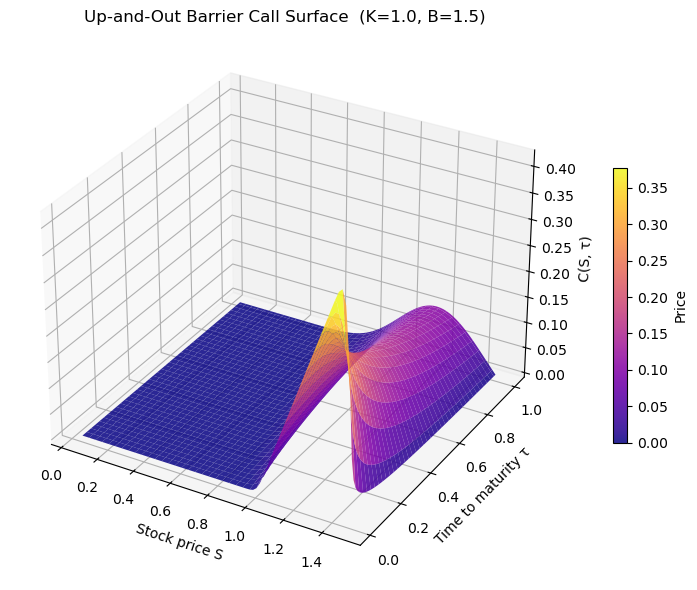

In [83]:
S_surf   = np.linspace(0.05, B-0.01, 80)
tau_surf = np.linspace(0.01, T, 80)
SS2, TT2 = np.meshgrid(S_surf, tau_surf)
CC2 = np.array([[barrier_call_cf(float(SS2[i,j]), K, B, r, sigma, float(TT2[i,j]))
                 for j in range(SS2.shape[1])] for i in range(SS2.shape[0])])

fig = plt.figure(figsize=(11, 6))
ax  = fig.add_subplot(111, projection='3d')
surf2 = ax.plot_surface(SS2, TT2, CC2, cmap='plasma', alpha=0.87)
fig.colorbar(surf2, ax=ax, shrink=0.5, label='Price')
ax.set_xlabel('Stock price S')
ax.set_ylabel('Time to maturity τ')
ax.set_zlabel('C(S, τ)')
ax.set_title(f'Up-and-Out Barrier Call Surface  (K={K}, B={B})')
plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/barrier_option_surface.png", dpi=150, bbox_inches='tight')
plt.show()

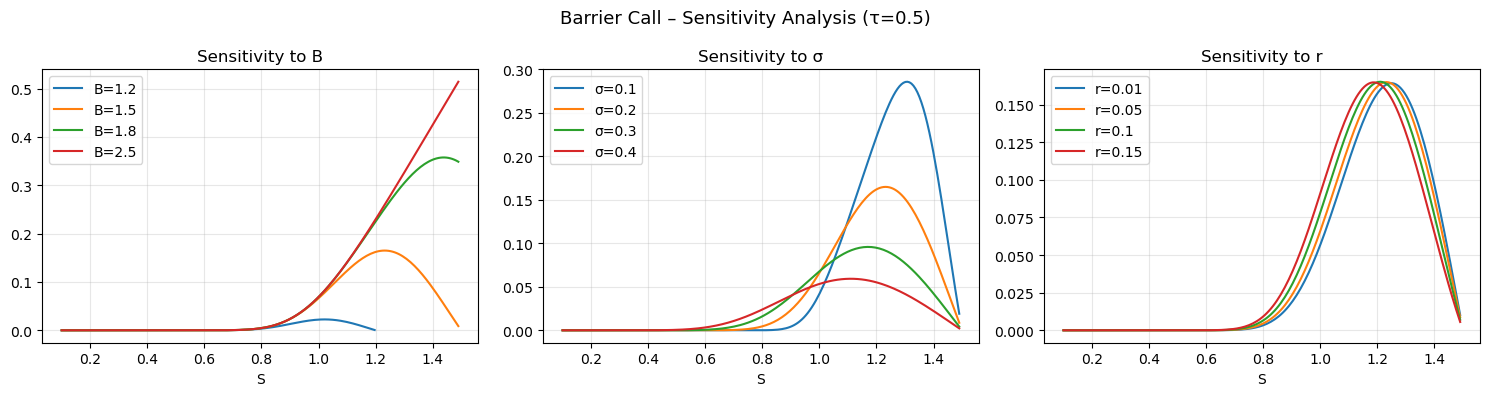

In [84]:
S_rng   = np.linspace(0.1, B-0.01, 200)
tau_fix = 0.5

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for Bv in [1.2, 1.5, 1.8, 2.5]:
    Sp = S_rng[S_rng < Bv]
    axes[0].plot(Sp, barrier_call_cf(Sp, K, Bv, r, sigma, tau_fix), label=f'B={Bv}')
axes[0].set_title('Sensitivity to B'); axes[0].set_xlabel('S'); axes[0].legend()

for sv in [0.1, 0.2, 0.3, 0.4]:
    axes[1].plot(S_rng, barrier_call_cf(S_rng, K, B, r, sv, tau_fix), label=f'σ={sv}')
axes[1].set_title('Sensitivity to σ'); axes[1].set_xlabel('S'); axes[1].legend()

for rv in [0.01, 0.05, 0.10, 0.15]:
    axes[2].plot(S_rng, barrier_call_cf(S_rng, K, B, rv, sigma, tau_fix), label=f'r={rv}')
axes[2].set_title('Sensitivity to r'); axes[2].set_xlabel('S'); axes[2].legend()

plt.suptitle('Barrier Call – Sensitivity Analysis (τ=0.5)', fontsize=13)
plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/barrier_sensitivity.png", dpi=150, bbox_inches='tight')
plt.show()

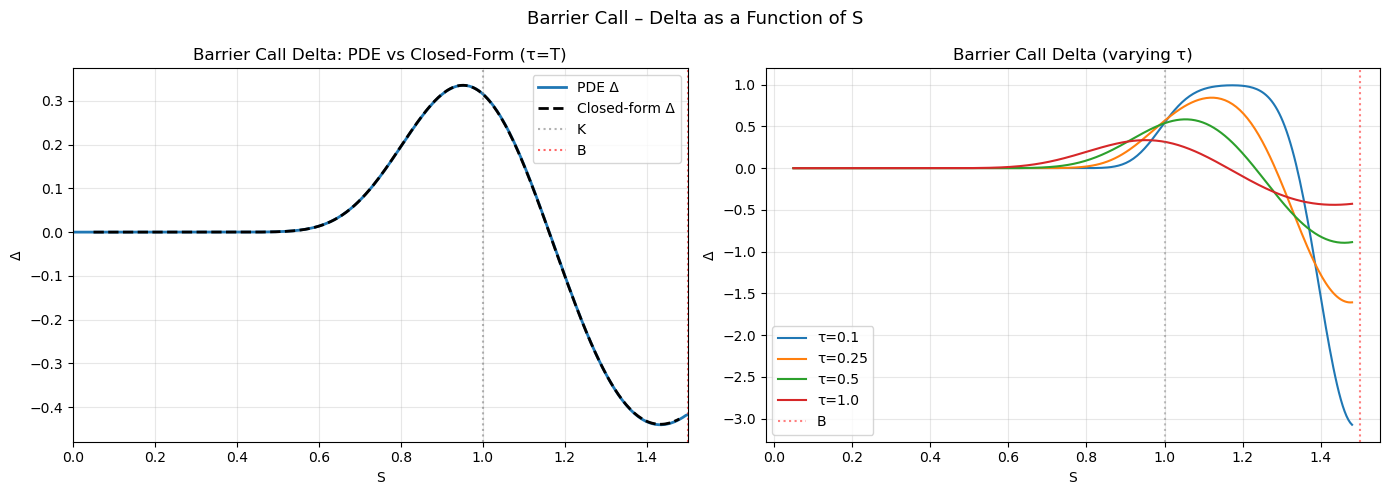

Note: delta turns negative as S approaches B,  the option becomes
increasingly likely to be knocked out, making it very hard to hedge near the barrier.


In [90]:
eps_S = 1e-4
S_d   = np.linspace(0.05, B-0.02, 300)

# Closed-form delta via central differences
cf_delta_b = (barrier_call_cf(S_d+eps_S, K,B,r,sigma,T) -
              barrier_call_cf(S_d-eps_S, K,B,r,sigma,T)) / (2*eps_S)

# PDE delta
delta_pde_b = np.gradient(V_b, S_b[1]-S_b[0])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(S_b, delta_pde_b, label='PDE Δ', lw=2)
axes[0].plot(S_d, cf_delta_b,  '--', label='Closed-form Δ', lw=2, color='k')
axes[0].axvline(K, color='gray', ls=':', alpha=0.6, label='K')
axes[0].axvline(B, color='red',  ls=':', alpha=0.6, label='B')
axes[0].set_xlim(0, B); axes[0].set_xlabel('S'); axes[0].set_ylabel('Δ')
axes[0].set_title('Barrier Call Delta: PDE vs Closed-Form (τ=T)'); axes[0].legend()

for tv in [0.1, 0.25, 0.5, 1.0]:
    Sp = np.linspace(0.05, B-0.02, 300)
    d  = (barrier_call_cf(Sp+eps_S,K,B,r,sigma,tv) -
          barrier_call_cf(Sp-eps_S,K,B,r,sigma,tv)) / (2*eps_S)
    axes[1].plot(Sp, d, label=f'τ={tv}')
axes[1].axvline(K, color='gray', ls=':', alpha=0.5)
axes[1].axvline(B, color='red',  ls=':', alpha=0.5, label='B')
axes[1].set_xlabel('S'); axes[1].set_ylabel('Δ')
axes[1].set_title('Barrier Call Delta (varying τ)'); axes[1].legend()

plt.suptitle('Barrier Call – Delta as a Function of S', fontsize=13)
plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/barrier_delta.png", dpi=150, bbox_inches='tight')
plt.show()

print("Note: delta turns negative as S approaches B,  the option becomes")
print("increasingly likely to be knocked out, making it very hard to hedge near the barrier.")